In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# OhioT1DM

In [ ]:
# Folder path
# 2018
folder_path_2018_test = '../1_OhioT1DM/2018/test'
folder_path_2018_train = '../1_OhioT1DM/2018/train'
# List all files in the folder
file_names_2018_test = [f for f in os.listdir(folder_path_2018_test) if os.path.isfile(os.path.join(folder_path_2018_test, f))]
file_names_2018_train = [f for f in os.listdir(folder_path_2018_train) if os.path.isfile(os.path.join(folder_path_2018_train, f))]


# 2020
folder_path_2020_test = '../1_OhioT1DM/2020/test'
folder_path_2020_train = '../1_OhioT1DM/2020/train'
file_names_2020_test = [f for f in os.listdir(folder_path_2020_test) if os.path.isfile(os.path.join(folder_path_2020_test, f))]
file_names_2020_train = [f for f in os.listdir(folder_path_2020_train) if os.path.isfile(os.path.join(folder_path_2020_train, f))]


In [3]:
# Initialize a dictionary to hold the unique date counts by subject ID
date_count_dict = {}

# Process files in the train folder
for input_file in file_names_2018_train:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2018_train, input_file)
    df = pd.read_csv(full_file_path)
    # Extract the date part from the timestamp
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    # Extract the subject ID from the file name (assuming the file name is like "123.csv")
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count

# Process files in the test folder
for input_file in file_names_2018_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2018_test, input_file)
    df = pd.read_csv(full_file_path)
    # Extract the date part from the timestamp
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    # Extract the subject ID from the file name (assuming the file name is like "123.csv")
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count

# Print the results
for subject_id, total_unique_dates in date_count_dict.items():
    print(f"Subject ID: {subject_id}, Total Unique Dates: {total_unique_dates}")

Subject ID: 591, Total Unique Dates: 53
Subject ID: 570, Total Unique Dates: 51
Subject ID: 559, Total Unique Dates: 52
Subject ID: 588, Total Unique Dates: 56
Subject ID: 563, Total Unique Dates: 56
Subject ID: 575, Total Unique Dates: 56


In [4]:
# Initialize a dictionary to hold the unique date counts by subject ID
# date_count_dict = {}

# Process files in the train folder
for input_file in file_names_2020_train:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_train, input_file)
    df = pd.read_csv(full_file_path)
    # Extract the date part from the timestamp
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    # Extract the subject ID from the file name (assuming the file name is like "123.csv")
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count

# Process files in the test folder
for input_file in file_names_2020_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_test, input_file)
    df = pd.read_csv(full_file_path)
    # Extract the date part from the timestamp
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    # Extract the subject ID from the file name (assuming the file name is like "123.csv")
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count

# Print the results
for subject_id, total_unique_dates in date_count_dict.items():
    print(f"Subject ID: {subject_id}, Total Unique Dates: {total_unique_dates}")

Subject ID: 591, Total Unique Dates: 53
Subject ID: 570, Total Unique Dates: 51
Subject ID: 559, Total Unique Dates: 52
Subject ID: 588, Total Unique Dates: 56
Subject ID: 563, Total Unique Dates: 56
Subject ID: 575, Total Unique Dates: 56
Subject ID: 544, Total Unique Dates: 52
Subject ID: 552, Total Unique Dates: 48
Subject ID: 584, Total Unique Dates: 57
Subject ID: 540, Total Unique Dates: 57
Subject ID: 596, Total Unique Dates: 57
Subject ID: 567, Total Unique Dates: 57


In [5]:
# Total number of days
Ohiot1dm_total_days = 0
for subject_id, total_unique_dates in date_count_dict.items():
    Ohiot1dm_total_days += total_unique_dates

In [6]:
Ohiot1dm_total_days

652

# T1DEXI

In [ ]:
folder_path_t1dexi = '../2_T1DEXI/'
file_names_t1dexi= [f for f in os.listdir(folder_path_t1dexi) if os.path.isfile(os.path.join(folder_path_t1dexi, f))]
date_count_dict_t1dexi = {}
date_count_dict = {}
# Process files in the train folder
for input_file in file_names_t1dexi:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_t1dexi, input_file)
    df = pd.read_csv(full_file_path)
    
    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict_t1dexi[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count

In [8]:
T1DEXI_total_days = 0
for subject_id, total_unique_dates in date_count_dict_t1dexi.items():
    T1DEXI_total_days += total_unique_dates

In [9]:
T1DEXI_total_days

13522

# BIG IDEA LAB dataset

In [ ]:
folder_path_bil = '../4_BIG_IDEA_LAB/'
file_names_bil= [f for f in os.listdir(folder_path_bil) if os.path.isfile(os.path.join(folder_path_bil, f))]
date_count_dict_bil = {}
date_count_dict = {}
# Process files in the train folder
for input_file in file_names_bil:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_bil, input_file)
    df = pd.read_csv(full_file_path)
    
    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict_bil[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count

In [11]:
bil_total_days = 0
for subject_id, total_unique_dates in date_count_dict_bil.items():
    bil_total_days += total_unique_dates

In [12]:
bil_total_days

150

# UCHTT1DM

In [ ]:
folder_path_uchtt1dm= '../10_UCHTT1DM/'
file_names_uchtt1dm= [f for f in os.listdir(folder_path_uchtt1dm) if os.path.isfile(os.path.join(folder_path_uchtt1dm, f))]
date_count_dict_uchtt1dm = {}
date_count_dict = {}
# Process files in the train folder
for input_file in file_names_uchtt1dm:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_uchtt1dm, input_file)
    df = pd.read_csv(full_file_path)
    
    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict_uchtt1dm[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count

In [14]:
uchtt1dm_total_days = 0
for subject_id, total_unique_dates in date_count_dict_uchtt1dm.items():
    uchtt1dm_total_days += total_unique_dates

In [15]:
uchtt1dm_total_days

127

# T1DiabetesGranada

In [ ]:
folder_path_T1DiabetesGranada= '../8_T1DiabetesGranada/'
file_names_T1DiabetesGranada= [f for f in os.listdir(folder_path_T1DiabetesGranada) if os.path.isfile(os.path.join(folder_path_T1DiabetesGranada, f))]
date_count_dict_T1DiabetesGranada = {}
date_count_dict = {}
# Process files in the train folder
for input_file in file_names_T1DiabetesGranada:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_T1DiabetesGranada, input_file)
    df = pd.read_csv(full_file_path)
    
    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict_T1DiabetesGranada[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count



In [17]:
T1DiabetesGranada_total_days = 0
for subject_id, total_unique_dates in date_count_dict_T1DiabetesGranada.items():
    T1DiabetesGranada_total_days += total_unique_dates

In [18]:
T1DiabetesGranada_total_days

257782

# DiaTrend

In [ ]:
import os
import pandas as pd

folder_path_diatrend = '../5_DiaTrend/'
file_names_diatrend = [f for f in os.listdir(folder_path_diatrend) if os.path.isfile(os.path.join(folder_path_diatrend, f))]
date_count_dict_diatrend = {}
date_count_dict = {}

for input_file in file_names_diatrend:
    full_file_path = os.path.join(folder_path_diatrend, input_file)
    df = pd.read_csv(full_file_path)

    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    
    # Save to dictionary
    date_count_dict_diatrend[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count


In [20]:
diatrend_total_days = 0
for subject_id, total_unique_dates in date_count_dict_diatrend.items():
    diatrend_total_days += total_unique_dates

diatrend_total_days

27663

# ShanghaiT1DM

In [ ]:
folder_path_shanghait1= '../6_ShanghaiT1DM/'
file_names_shanghait1= [f for f in os.listdir(folder_path_shanghait1) if os.path.isfile(os.path.join(folder_path_shanghait1, f))]
date_count_dict_shanghait1 = {}
date_count_dict = {}
# Process files in the train folder
date_count_dict = {}
for input_file in file_names_shanghait1:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_shanghait1, input_file)
    df = pd.read_csv(full_file_path)
    
    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict_shanghait1[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count



In [22]:
shanghait1_total_days = 0
for subject_id, total_unique_dates in date_count_dict_shanghait1.items():
    shanghait1_total_days += total_unique_dates

shanghait1_total_days

181

# ShanghaiT2DM

In [ ]:
folder_path_shanghait2= '../7_ShanghaiT2DM/'
file_names_shanghait2= [f for f in os.listdir(folder_path_shanghait2) if os.path.isfile(os.path.join(folder_path_shanghait2, f))]
date_count_dict_shanghait2 = {}
date_count_dict = {}
# Process files in the train folder

for input_file in file_names_shanghait2:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_shanghait2, input_file)
    df = pd.read_csv(full_file_path)
    
    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict_shanghait2[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count



In [24]:
shanghait2_total_days = 0
for subject_id, total_unique_dates in date_count_dict_shanghait2.items():
    shanghait2_total_days += total_unique_dates

shanghait2_total_days

1292

# 9_AI-READI

In [ ]:
folder_path_AI_READI = '../9_AI-READI/'
file_names_AI_READI = [f for f in os.listdir(folder_path_AI_READI) if os.path.isfile(os.path.join(folder_path_AI_READI, f))]

date_count_dict = {}
# Process files in the train folder
date_count_dict_AI_READI = {}
for input_file in file_names_AI_READI:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_AI_READI, input_file)
    df = pd.read_csv(full_file_path)
    
    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict_AI_READI[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count



In [26]:
AI_READI_total_days = 0
for subject_id, total_unique_dates in date_count_dict_AI_READI.items():
    AI_READI_total_days += total_unique_dates

AI_READI_total_days

11181

# CGMacros

In [ ]:
folder_path_CGMacros = '../11_CGMacros/Dexcom GL'
file_names_CGMacros = [f for f in os.listdir(folder_path_CGMacros) if os.path.isfile(os.path.join(folder_path_CGMacros, f))]

date_count_dict = {}
# Process files in the train folder
date_count_dict_CGMacros = {}
for input_file in file_names_CGMacros:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_CGMacros, input_file)
    df = pd.read_csv(full_file_path)
    
    # Adaptively parse timestamps with mixed formats
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    
    # Skip files with completely unparseable timestamps
    if df['timestamp'].isna().all():
        print(f"Warning: No valid timestamps in {input_file}")
        continue

    # Extract the date
    df['date'] = df['timestamp'].dt.date
    
    # Count the number of unique dates
    unique_dates_count = df['date'].nunique()
    
    # Get subject ID from filename
    subject_id = os.path.splitext(input_file)[0]
    # Add the count to the dictionary
    date_count_dict_CGMacros[subject_id] = date_count_dict.get(subject_id, 0) + unique_dates_count



In [28]:
CGMacros_total_days = 0
for subject_id, total_unique_dates in date_count_dict_CGMacros.items():
    CGMacros_total_days += total_unique_dates

CGMacros_total_days

493

# Plot Figure 1-B

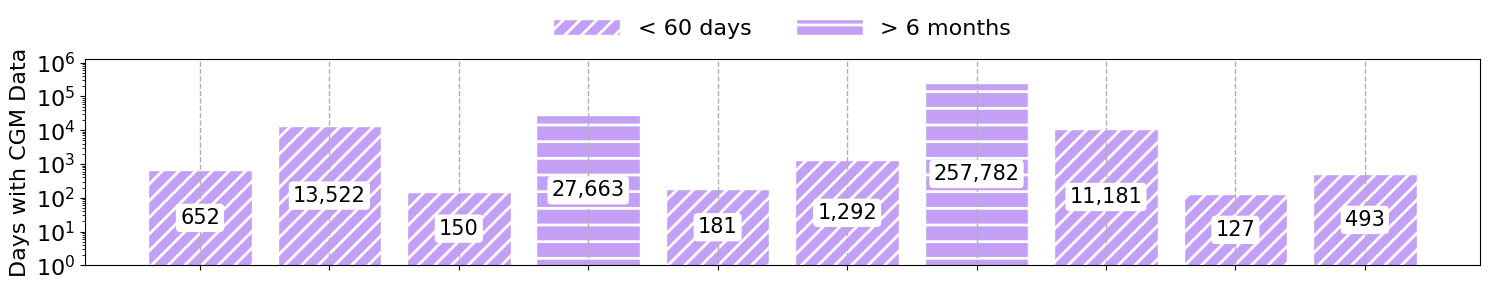

In [100]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
mpl.rcParams['hatch.linewidth'] = 2.0  # Wider lines

# Example dictionary with dataset names and the number of days with CGM data
# Replace this with your actual data
dataset_days = {
    'OhioT1DM': Ohiot1dm_total_days,
    'T1DEXI': T1DEXI_total_days,
    'BIL': bil_total_days,
    'DiaTrend': diatrend_total_days,
    'ShanghaiT1DM': shanghait1_total_days,
    'ShanghaiT2DM': shanghait2_total_days,
    'T1DiabetesGranada': T1DiabetesGranada_total_days,
    'AI_READI': AI_READI_total_days,
    'UCHTT1DM': uchtt1dm_total_days,
    'CGMacros' : CGMacros_total_days
}

mean_days_per_participant = {
    'OhioT1DM': 54.33,
    'T1DEXI': 27.21,
    'BIL': 9.38,
    'DiaTrend': 512.28,
    'ShanghaiT1DM': 15.08,
    'ShanghaiT2DM': 12.92,
    'T1DiabetesGranada': 350.25,
    'AI_READI': 10.66,
    'UCHTT1DM': 6.35,
    'CGMacros': 10.96
}

# Extract dataset names and number of days

datasets = list(dataset_days.keys())
num_days = list(dataset_days.values())

# Create bar plot
plt.figure(figsize=(15, 3))
bars = plt.bar(dataset_days.keys(), dataset_days.values(), color='#C39FF5', edgecolor='black')#F48BBF
plt.yscale('log')

# Add labels and title
plt.xlabel('', fontsize=16)
plt.ylabel('Days with CGM Data', fontsize=16)
# plt.title('Number of Days with CGM Data per Dataset', fontsize=14)
plt.xticks([])
plt.yticks(fontsize=16)
# Define hatching patterns
short_duration_pattern = '//'  # for < 60 days
long_duration_pattern = '-'   # for > 180 days

for bar, dataset in zip(bars, datasets):
    mean_days = mean_days_per_participant.get(dataset, None)
    if mean_days is not None:
        if mean_days < 60:
            bar.set_hatch(short_duration_pattern)
            bar.set_edgecolor('white')  # White hatch lines
        elif mean_days > 180:
            bar.set_hatch(long_duration_pattern)
            bar.set_edgecolor('white')  # White hatch lines


for bar in bars:
    height = bar.get_height()
    y_center = np.sqrt(1 * height)  # geometric mean between 1 and height
    plt.annotate(f'{height:,}',
                 xy=(bar.get_x() + bar.get_width() / 2, y_center),
                 ha='center',
                 va='center',
                 fontsize=15,
                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))
# Adjust the y-scale to include the highest text box

# Add legend
# Create legend entries
short_duration_patch = mpatches.Patch(facecolor='#C39FF5', edgecolor='white', hatch='//', label='< 60 days')
long_duration_patch = mpatches.Patch(facecolor='#C39FF5', edgecolor='white', hatch='-', label='> 6 months')

# Add legend above the figure
plt.legend(handles=[short_duration_patch, long_duration_patch],
           loc='lower center',
           bbox_to_anchor=(0.5, 1.0),
           ncol=2,
           handlelength=3,
           fontsize=16,
           frameon=False)

plt.ylim(1, max(num_days) * 5)  # Extend the y-axis by 20% above the highest bar
# Restore ticks without labels
plt.xticks(ticks=range(len(datasets)), labels=['']*len(datasets))
plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)

plt.grid(True, axis='x', which='both', linestyle='--', linewidth=1)
plt.tight_layout()

plt.show()

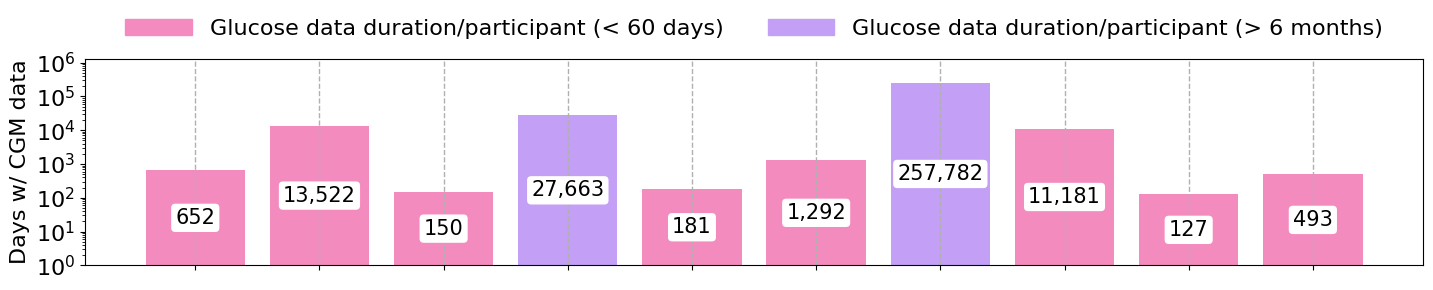

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Example dictionary with dataset names and the number of days with CGM data
dataset_days = {
    'OhioT1DM': Ohiot1dm_total_days,
    'T1DEXI': T1DEXI_total_days,
    'BIL': bil_total_days,
    'DiaTrend': diatrend_total_days,
    'ShanghaiT1DM': shanghait1_total_days,
    'ShanghaiT2DM': shanghait2_total_days,
    'T1DiabetesGranada': T1DiabetesGranada_total_days,
    'AI_READI': AI_READI_total_days,
    'UCHTT1DM': uchtt1dm_total_days,
    'CGMacros': CGMacros_total_days
}

mean_days_per_participant = {
    'OhioT1DM': 54.33,
    'T1DEXI': 27.21,
    'BIL': 9.38,
    'DiaTrend': 512.28,
    'ShanghaiT1DM': 15.08,
    'ShanghaiT2DM': 12.92,
    'T1DiabetesGranada': 350.25,
    'AI_READI': 10.66,
    'UCHTT1DM': 6.35,
    'CGMacros': 10.96
}

# Color settings
short_duration_color = '#F48BBF'  # e.g., pink
long_duration_color = '#C39FF5'   # e.g., purple

# Extract dataset names and number of days
datasets = list(dataset_days.keys())
num_days = list(dataset_days.values())

# Assign colors based on mean_days_per_participant
bar_colors = []
for dataset in datasets:
    mean_days = mean_days_per_participant.get(dataset, 0)
    if mean_days < 60:
        bar_colors.append(short_duration_color)
    elif mean_days > 180:
        bar_colors.append(long_duration_color)
    else:
        bar_colors.append(short_duration_color)  # You said no middle zone

# Create bar plot
plt.figure(figsize=(15, 3))
bars = plt.bar(datasets, num_days, color=bar_colors)
plt.yscale('log')

# Annotate bars
for bar in bars:
    height = bar.get_height()
    y_center = np.sqrt(height)
    plt.annotate(f'{height:,}',
                 xy=(bar.get_x() + bar.get_width() / 2, y_center),
                 ha='center',
                 va='center',
                 fontsize=15,
                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))

# Axis settings
plt.ylabel('Days w/ CGM data', fontsize=16)
plt.xticks(ticks=range(len(datasets)), labels=[''] * len(datasets))
plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
plt.yticks(fontsize=16)
plt.ylim(1, max(num_days) * 5)
plt.grid(True, axis='x', which='both', linestyle='--', linewidth=1)

# Legend
short_patch = mpatches.Patch(color=short_duration_color, label='Glucose data duration/participant (< 60 days)')
long_patch = mpatches.Patch(color=long_duration_color, label='Glucose data duration/participant (> 6 months)')

plt.legend(handles=[short_patch, long_patch],
           loc='lower center',
           bbox_to_anchor=(0.5, 1.0),
           ncol=2,
           handlelength=3,
           fontsize=16,
           frameon=False)

plt.tight_layout()
plt.show()


# Plot Figure 1-A

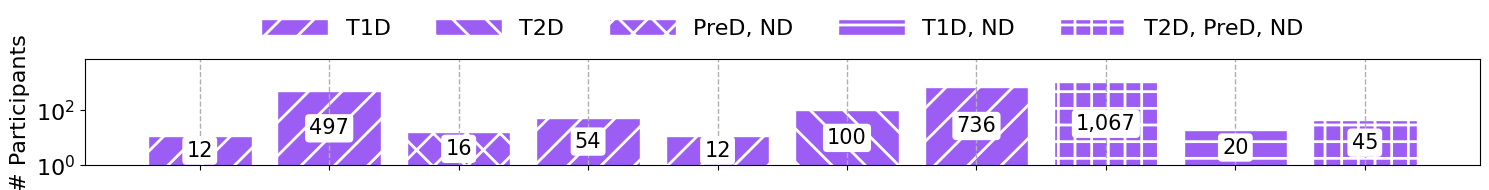

In [101]:
import matplotlib.pyplot as plt

# Data
values = [12, 497, 16, 54, 12, 100, 736, 1067, 20, 45]
labels = [f"Item {i+1}" for i in range(len(values))]  # Generate labels for each bar

cohorts = ["T1D",
          "T1D",
          "PreD, ND",
          "T1D",
          "T1D",
          "T2D",
          "T1D",
          "T2D, PreD, ND",
          "T1D, ND",
          "T2D, PreD, ND"]

pattern_map = {
    "T1D": '/',
    "T2D": '\\',
    "PreD, ND": 'x',
    "T1D, ND": '-',
    "T2D, PreD, ND": '+'
}


# Plot setup
plt.figure(figsize=(15, 2))
bars = plt.bar(labels, values, color='#9C5DF5', edgecolor='black')
plt.yscale('log')

# Add labels and title
# plt.xlabel('Items', fontsize=14)
plt.ylabel('# Participants', fontsize=16)
# plt.title('Bar Plot of Given Values', fontsize=16)
plt.yticks(fontsize=16)

# Annotate bars
for bar, cohort in zip(bars, cohorts):
    height = bar.get_height()
    y_center = np.sqrt(1 * height)
    pattern = pattern_map.get(cohort, None)
    if pattern:
        bar.set_hatch(pattern)
        bar.set_edgecolor('white')
    plt.annotate(f'{height:,}',
                 xy=(bar.get_x() + bar.get_width() / 2, y_center),
                 ha='center',
                 va='center',
                 fontsize=15,
                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))


# for bar in bars:
#     height = bar.get_height()
#     y_center = np.sqrt(1 * height)  # geometric mean between 1 and height
#     plt.annotate(f'{height:,}',
#                  xy=(bar.get_x() + bar.get_width() / 2, y_center),
#                  ha='center',
#                  va='center',
#                  fontsize=15,
#                  bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))

# Adjust x-ticks for better readability
plt.xticks(ticks=range(len(values)), labels=['']*len(values))
plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
plt.ylim(1, max(values)*7) 
plt.grid(True, axis='x', which='both', linestyle='--', linewidth=1)

# Legend: create proxy patches for each pattern
legend_patches = [
    mpatches.Patch(facecolor='#9C5DF5', edgecolor='white', hatch=pattern, label=label)
    for label, pattern in pattern_map.items()
]

# Add horizontal legend above the figure
plt.legend(handles=legend_patches,
           loc='lower center',
           bbox_to_anchor=(0.5, 1),
           ncol=len(pattern_map),
           handlelength=3,
           fontsize=16,
           frameon=False)

plt.tight_layout()
plt.show()

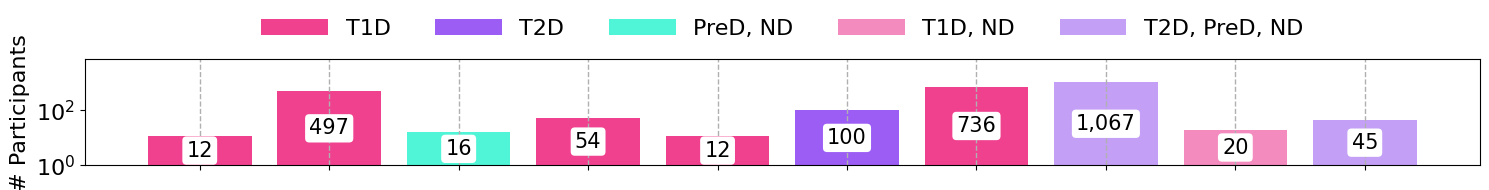

In [106]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
values = [12, 497, 16, 54, 12, 100, 736, 1067, 20, 45]
labels = [f"Item {i+1}" for i in range(len(values))]

cohorts = [
    "T1D",
    "T1D",
    "PreD, ND",
    "T1D",
    "T1D",
    "T2D",
    "T1D",
    "T2D, PreD, ND",
    "T1D, ND",
    "T2D, PreD, ND"
]

# Define distinct colors for each cohort group
color_map = {
    "T1D": '#F0418F',            # purple
    "T2D": '#9C5DF5',            # pink
    "PreD, ND": '#4FF5D6',       # teal
    "T1D, ND": '#F48BBF',        # lavender
    "T2D, PreD, ND": '#C39FF5'   # yellow-orange
}

# Assign colors per bar based on cohort
bar_colors = [color_map.get(cohort, '#CCCCCC') for cohort in cohorts]

# Plot setup
plt.figure(figsize=(15, 2))
bars = plt.bar(labels, values, color=bar_colors)
plt.yscale('log')

# Y-axis label and ticks
plt.ylabel('# Participants', fontsize=16)
plt.yticks(fontsize=16)

# Annotate bars
for bar, height in zip(bars, values):
    y_center = np.sqrt(height)
    plt.annotate(f'{height:,}',
                 xy=(bar.get_x() + bar.get_width() / 2, y_center),
                 ha='center',
                 va='center',
                 fontsize=15,
                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))

# Clean x-axis ticks
plt.xticks(ticks=range(len(values)), labels=[''] * len(values))
plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
plt.ylim(1, max(values) * 7)
plt.grid(True, axis='x', which='both', linestyle='--', linewidth=1)

# Create legend from color_map
legend_patches = [
    mpatches.Patch(facecolor=color, label=label)
    for label, color in color_map.items()
]

# Add legend above plot
plt.legend(handles=legend_patches,
           loc='lower center',
           bbox_to_anchor=(0.5, 1),
           ncol=len(color_map),
           handlelength=3,
           fontsize=16,
           frameon=False)

plt.tight_layout()
plt.show()
